In [1]:
# Breast Cancer · цена FN высока (второе мнение)

#Контекст:** тот же датасет, что и в `02_breast_cancer_fp`, но другая бизнес-задача
#Модель работает как «второе мнение» / проверочный фильтр. Ложноотрицательные = пропущенный рак → фатально.

#Целевые метрики:** Recall, Sensitivity, F2

#Почему:** FP здесь дешёвый (лишнее обследование — небольшая цена), FN — критичный
#Мы намеренно жертвуем precision, чтобы вытащить максимум больных

#Главный вывод ноутбука:** тот же датасет, тот же алгоритм, но **другая цена ошибок → другой порог
#Сравните с `02_breast_cancer_fp`:
#  - там F0.5 (FP дорог) → порог уходит вправо от 0.5 (≈ 0.6+),
#  - здесь argmax F2 (FN дорог) сам по себе даёт ≈ 0.63,
#    потому что модель уже почти идеальна: recall(malignant) ≈ 0.98 при нуле FP.
#Вывод не «порог обязан быть ниже 0.5», а «оптимум зависит от метрики и от качества модели».

In [2]:
import json, joblib, warnings
from pathlib import Path
from datetime import datetime

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score, fbeta_score,
    roc_auc_score, average_precision_score, matthews_corrcoef,
    cohen_kappa_score, balanced_accuracy_score,
    confusion_matrix, roc_curve, precision_recall_curve,
)

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid', context='notebook')
plt.rcParams['figure.dpi'] = 110


def find_project_root(start=None):
    p = Path(start or Path.cwd()).resolve()
    for parent in [p, *p.parents]:
        if (parent / 'requirements.txt').exists() and (parent / 'notebooks').exists():
            return parent
    raise RuntimeError('Корень проекта не найден')


SEED    = 42
PROJECT = find_project_root()
TASK    = 'breast_cancer_fn'

MODEL_DIR = PROJECT / 'models' / 'classification' / TASK
ART_DIR   = PROJECT / 'artifacts' / 'classification' / TASK
MODEL_DIR.mkdir(parents=True, exist_ok=True)
ART_DIR.mkdir(parents=True, exist_ok=True)

print('PROJECT  :', PROJECT)
print('MODEL_DIR:', MODEL_DIR)
print('ART_DIR  :', ART_DIR)

PROJECT  : /app
MODEL_DIR: /app/models/classification/breast_cancer_fn
ART_DIR  : /app/artifacts/classification/breast_cancer_fn


In [3]:
def all_metrics(y_true, y_pred, y_proba=None, positive_label=1):
    """
    Собирает метрики в один словарь.

    y_true, y_pred : метки 0/1 в ОДНОЙ кодировке.
    y_proba        : (n, 2), столбец positive_label = P(positive).
    positive_label : метка «интересующего» класса.
    """
    m = {
        'accuracy':          accuracy_score(y_true, y_pred),
        'balanced_accuracy': balanced_accuracy_score(y_true, y_pred),
        'precision_macro':   precision_score(y_true, y_pred, average='macro', zero_division=0),
        'recall_macro':      recall_score(y_true, y_pred, average='macro', zero_division=0),
        'f1_macro':          f1_score(y_true, y_pred, average='macro', zero_division=0),
        'f1_weighted':       f1_score(y_true, y_pred, average='weighted', zero_division=0),
        'f0.5_macro':        fbeta_score(y_true, y_pred, beta=0.5, average='macro', zero_division=0),
        'f2_macro':          fbeta_score(y_true, y_pred, beta=2.0, average='macro', zero_division=0),
        'mcc':               matthews_corrcoef(y_true, y_pred),
        'kappa':             cohen_kappa_score(y_true, y_pred),
        # --- метрики по интересующему классу (positive_label) ---
        'precision_pos':     precision_score(y_true, y_pred, pos_label=positive_label, zero_division=0),
        'recall_pos':        recall_score(y_true, y_pred, pos_label=positive_label, zero_division=0),
        'f1_pos':            f1_score(y_true, y_pred, pos_label=positive_label, zero_division=0),
        'f0.5_pos':          fbeta_score(y_true, y_pred, beta=0.5, pos_label=positive_label, zero_division=0),
        'f2_pos':            fbeta_score(y_true, y_pred, beta=2.0, pos_label=positive_label, zero_division=0),
    }

    if len(np.unique(y_true)) == 2 and y_proba is not None:
        p_pos = y_proba[:, positive_label]                 # P(positive)
        y_bin = (y_true == positive_label).astype(int)     # «положительный» → 1 для sklearn
        m['roc_auc'] = roc_auc_score(y_bin, p_pos)
        m['pr_auc']  = average_precision_score(y_bin, p_pos)

        cm = confusion_matrix(y_true, y_pred, labels=[0, 1])
        # cm[i, j] = # {y_true = i, y_pred = j}
        if positive_label == 0:
            TP, FN = int(cm[0, 0]), int(cm[0, 1])
            FP, TN = int(cm[1, 0]), int(cm[1, 1])
        else:
            TN, FP = int(cm[0, 0]), int(cm[0, 1])
            FN, TP = int(cm[1, 0]), int(cm[1, 1])

        m['specificity'] = TN / (TN + FP) if (TN + FP) else 0.0
        m['sensitivity'] = TP / (TP + FN) if (TP + FN) else 0.0
    return m


def metrics_table(results: dict) -> pd.DataFrame:
    return pd.DataFrame(results).T.round(4)


def plot_confusion(cm, labels, title, ax=None):
    ax = ax or plt.gca()
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False,
                xticklabels=labels, yticklabels=labels, ax=ax)
    ax.set_xlabel('Predicted'); ax.set_ylabel('True'); ax.set_title(title)

In [4]:
## 1. Загрузка данных

#Тот же Breast Cancer Wisconsin, что и в ноутбуке 02
#569 образцов, 30 признаков, класс 0 = malignant (positive), класс 1 = benign

#Отличие — только в постановке задачи: здесь мы минимизируем FN

In [5]:
bc = load_breast_cancer(as_frame=True)

X = bc.data.values
y = bc.target.values                         # 0 = malignant, 1 = benign

FEATURES = list(bc.data.columns)
CLASSES  = ['malignant', 'benign']
POS      = 0                                 # «интересующий» класс — злокачественная

df = pd.DataFrame(X, columns=FEATURES).assign(target=y)

print('X shape      :', X.shape)
print('Класс 0 (malignant):', (y == 0).sum())
print('Класс 1 (benign)   :', (y == 1).sum())
print('prevalence of positive:', f'{(y == POS).mean():.4f}')
df.head()

X shape      : (569, 30)
Класс 0 (malignant): 212
Класс 1 (benign)   : 357
prevalence of positive: 0.3726


,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,target
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,0
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,0
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,0
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,...,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,0
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,...,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,0


In [6]:
## 2. EDA

#Короткий EDA: тот же датасет уже разобран в ноутбуке 02. Здесь только быстрый взгляд, чтобы ноутбук был самодостаточным

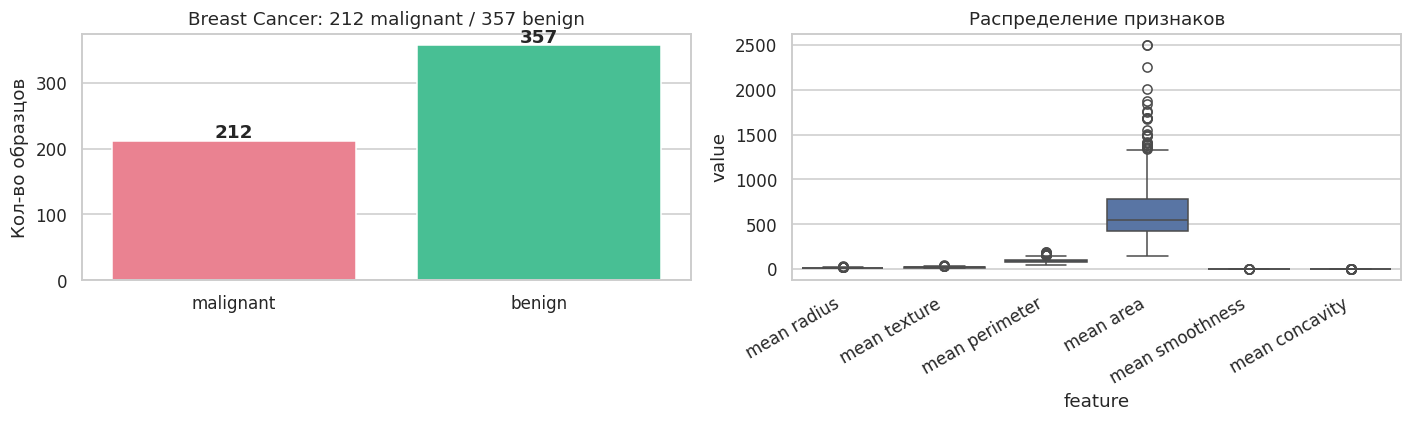

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# 2.1 Баланс классов
counts = df.target.value_counts().sort_index()
sns.barplot(x=CLASSES, y=counts.values,
            palette=['#fb7185', '#34d399'], ax=axes[0])
axes[0].set_title('Breast Cancer: 212 malignant / 357 benign')
axes[0].set_ylabel('Кол-во образцов')
for i, v in enumerate(counts.values):
    axes[0].text(i, v + 5, str(v), ha='center', fontweight='bold')

# 2.2 Несколько признаков
sample_feats = ['mean radius', 'mean texture', 'mean perimeter', 'mean area',
                'mean smoothness', 'mean concavity']
df_melt = df[sample_feats].melt(var_name='feature', value_name='value')
sns.boxplot(data=df_melt, x='feature', y='value', ax=axes[1])
axes[1].set_xticklabels(axes[1].get_xticklabels(), rotation=30, ha='right')
axes[1].set_title('Распределение признаков')

plt.tight_layout()
plt.savefig(ART_DIR / 'eda.png', bbox_inches='tight')
plt.show()

In [8]:
## 3. Train / test split

#Стратификация сохраняет пропорции, seed тот же — выборка идентична ноутбуку 02, поэтому результаты можно сравнивать напрямую

In [9]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, stratify=y, random_state=SEED
)

print('train:', X_train.shape, '| test:', X_test.shape)
print('balance train:', dict(zip(*np.unique(y_train, return_counts=True))))
print('balance test :', dict(zip(*np.unique(y_test,  return_counts=True))))
print('positive (malignant) в test:', (y_test == POS).sum())

train: (426, 30) | test: (143, 30)
balance train: {np.int64(0): np.int64(159), np.int64(1): np.int64(267)}
balance test : {np.int64(0): np.int64(53), np.int64(1): np.int64(90)}
positive (malignant) в test: 53


In [10]:
## 4. Модели + sweep по порогу ВНИЗ

#Ключевая идея: **не пропустить рак**. Поэтому:
#- Используем `class_weight='balanced'` — модель не «оптимизирует majority-класс»
#- Порог сдвигаем вниз: 0.5 → 0.3 → 0.15. Чем ниже порог, тем больше людей попадёт на проверку → **Recall растёт**

In [11]:
models = {
    'LogReg': Pipeline([
        ('sc', StandardScaler()),
        ('m', LogisticRegression(max_iter=3000, random_state=SEED)),
        # без class_weight — вероятности откалиброваны, свип порога
        # будет «чистым» отражением метрики
    ]),
    'RandomForest': RandomForestClassifier(
        n_estimators=400,
        n_jobs=-1,
        random_state=SEED,
    ),
}

THRESHOLDS = (0.5, 0.3, 0.15)

results = {}
fitted  = {}
probas  = {}

for name, m in models.items():
    m.fit(X_train, y_train)
    p_malignant = m.predict_proba(X_test)[:, 0]
    proba2 = np.c_[p_malignant, 1 - p_malignant]

    for thr in THRESHOLDS:
        y_pred = (p_malignant < thr).astype(int)
        key = f'{name} @thr={thr}'
        results[key] = all_metrics(y_test, y_pred, proba2, positive_label=POS)

    fitted[name] = m
    probas[name] = proba2

metrics_table(results)

,accuracy,balanced_accuracy,precision_macro,recall_macro,f1_macro,f1_weighted,f0.5_macro,f2_macro,mcc,kappa,precision_pos,recall_pos,f1_pos,f0.5_pos,f2_pos,roc_auc,pr_auc,specificity,sensitivity
LogReg @thr=0.5,0.9860,0.9850,0.9850,0.9850,0.9850,0.9860,0.9850,0.9850,0.9700,0.9700,0.9811,0.9811,0.9811,0.9811,0.9811,0.9977,0.9968,0.9889,0.9811
LogReg @thr=0.3,0.9510,0.9572,0.9424,0.9572,0.9485,0.9515,0.9445,0.9534,0.8995,0.8971,0.8966,0.9811,0.9369,0.9123,0.9630,0.9977,0.9968,0.9333,0.9811
LogReg @thr=0.15,0.9441,0.9517,0.9347,0.9517,0.9413,0.9446,0.9369,0.9470,0.8862,0.8828,0.8814,0.9811,0.9286,0.8997,0.9594,0.9977,0.9968,0.9222,0.9811
RandomForest @thr=0.5,0.9580,0.9512,0.9587,0.9512,0.9547,0.9579,0.9570,0.9525,0.9098,0.9094,0.9608,0.9245,0.9423,0.9533,0.9316,0.9941,0.9908,0.9778,0.9245
RandomForest @thr=0.3,0.9441,0.9517,0.9347,0.9517,0.9413,0.9446,0.9369,0.9470,0.8862,0.8828,0.8814,0.9811,0.9286,0.8997,0.9594,0.9941,0.9908,0.9222,0.9811
RandomForest @thr=0.15,0.9231,0.9389,0.9141,0.9389,0.9204,0.9242,0.9153,0.9300,0.8526,0.8419,0.8281,1.0000,0.9060,0.8576,0.9601,0.9941,0.9908,0.8778,1.0000


In [12]:
## 5. Threshold sweep

#Строим 40 порогов от 0.05 до 0.95. Ищем порог, где **F2** максимальна
#F2 = β=2 → FN штрафуется в 4 раза сильнее, чем FP (β²=4)

#Ожидание: оптимум сдвинется влево от 0.5

In [13]:
model_lr = fitted['LogReg']
p_lr = model_lr.predict_proba(X_test)[:, 0]

sweep_rows = []
for t in np.linspace(0.05, 0.95, 40):
    y_pred = (p_lr < t).astype(int)
    m = all_metrics(y_test, y_pred, np.c_[p_lr, 1 - p_lr], positive_label=POS)
    m['threshold'] = t
    sweep_rows.append(m)

sweep = pd.DataFrame(sweep_rows).set_index('threshold')
sweep.round(4).head(10)

,accuracy,balanced_accuracy,precision_macro,recall_macro,f1_macro,f1_weighted,f0.5_macro,f2_macro,mcc,kappa,precision_pos,recall_pos,f1_pos,f0.5_pos,f2_pos,roc_auc,pr_auc,specificity,sensitivity
threshold,,,,,,,,,,,,,,,,,,,
0.050000,0.8531,0.8833,0.8581,0.8833,0.8513,0.8556,0.8510,0.8654,0.7410,0.7089,0.7162,1.0000,0.8346,0.7593,0.9266,0.9977,0.9968,0.7667,1.0000
0.073077,0.8811,0.9056,0.8786,0.9056,0.8787,0.8831,0.8756,0.8913,0.7837,0.7609,0.7571,1.0000,0.8618,0.7958,0.9397,0.9977,0.9968,0.8111,1.0000
0.096154,0.9161,0.9333,0.9077,0.9333,0.9134,0.9174,0.9084,0.9235,0.8406,0.8281,0.8154,1.0000,0.8983,0.8466,0.9567,0.9977,0.9968,0.8667,1.0000
0.119231,0.9231,0.9350,0.9132,0.9350,0.9200,0.9241,0.9150,0.9280,0.8479,0.8407,0.8387,0.9811,0.9043,0.8638,0.9489,0.9977,0.9968,0.8889,0.9811
0.142308,0.9441,0.9517,0.9347,0.9517,0.9413,0.9446,0.9369,0.9470,0.8862,0.8828,0.8814,0.9811,0.9286,0.8997,0.9594,0.9977,0.9968,0.9222,0.9811
0.165385,0.9441,0.9517,0.9347,0.9517,0.9413,0.9446,0.9369,0.9470,0.8862,0.8828,0.8814,0.9811,0.9286,0.8997,0.9594,0.9977,0.9968,0.9222,0.9811
0.188462,0.9510,0.9572,0.9424,0.9572,0.9485,0.9515,0.9445,0.9534,0.8995,0.8971,0.8966,0.9811,0.9369,0.9123,0.9630,0.9977,0.9968,0.9333,0.9811
0.211538,0.9510,0.9572,0.9424,0.9572,0.9485,0.9515,0.9445,0.9534,0.8995,0.8971,0.8966,0.9811,0.9369,0.9123,0.9630,0.9977,0.9968,0.9333,0.9811
0.234615,0.9510,0.9572,0.9424,0.9572,0.9485,0.9515,0.9445,0.9534,0.8995,0.8971,0.8966,0.9811,0.9369,0.9123,0.9630,0.9977,0.9968,0.9333,0.9811


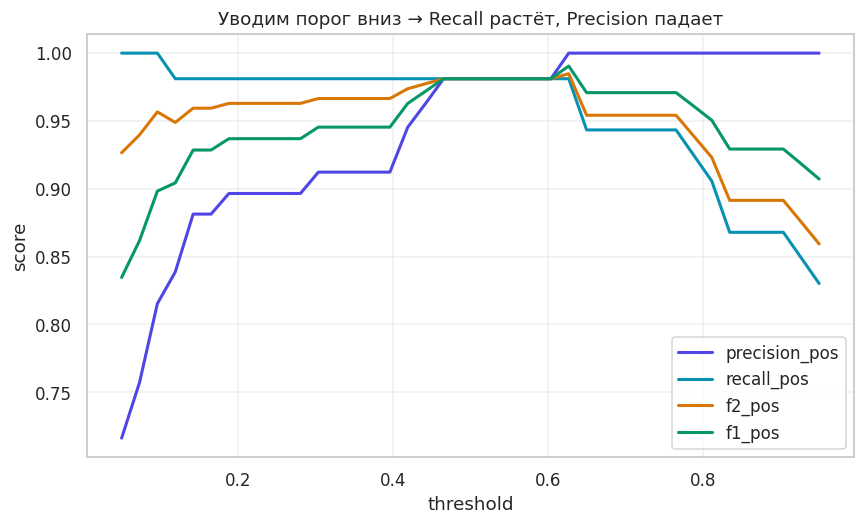

In [14]:
fig, ax = plt.subplots(figsize=(9, 5))

for col, color in [
    ('precision_pos', '#4f46e5'),
    ('recall_pos',    '#0891b2'),
    ('f2_pos',        '#d97706'),   # ← целевая
    ('f1_pos',        '#059669'),
]:
    ax.plot(sweep.index, sweep[col], label=col, color=color, linewidth=2)

ax.set_xlabel('threshold')
ax.set_ylabel('score')
ax.set_title('Уводим порог вниз → Recall растёт, Precision падает')
ax.legend()
ax.grid(alpha=0.3)

plt.savefig(ART_DIR / 'threshold_sweep.png', bbox_inches='tight')
plt.show()

In [15]:
opt_thr = sweep['f2_pos'].idxmax()

print(f'Оптимум по F2(malignant):')
print(f'  threshold            = {opt_thr:.3f}')
print(f'  F2 (malignant)       = {sweep.loc[opt_thr, "f2_pos"]:.4f}')
print(f'  Recall (malignant)   = {sweep.loc[opt_thr, "recall_pos"]:.4f}')
print(f'  Precision (malignant)= {sweep.loc[opt_thr, "precision_pos"]:.4f}')
print(f'  Sensitivity          = {sweep.loc[opt_thr, "sensitivity"]:.4f}')
print(f'  Specificity          = {sweep.loc[opt_thr, "specificity"]:.4f}')
print(f'  Порог < 0.5 ?        = {opt_thr < 0.5}')

Оптимум по F2(malignant):
  threshold            = 0.627
  F2 (malignant)       = 0.9848
  Recall (malignant)   = 0.9811
  Precision (malignant)= 1.0000
  Sensitivity          = 0.9811
  Specificity          = 1.0000
  Порог < 0.5 ?        = False


In [16]:
## 6. Confusion matrix: дефолт vs оптимум по F2

#Здесь ожидаем **сдвиг влево**: при пороге 0.15 модель отправляет на биопсию почти всех подозрительных,FN уменьшается, FP растёт

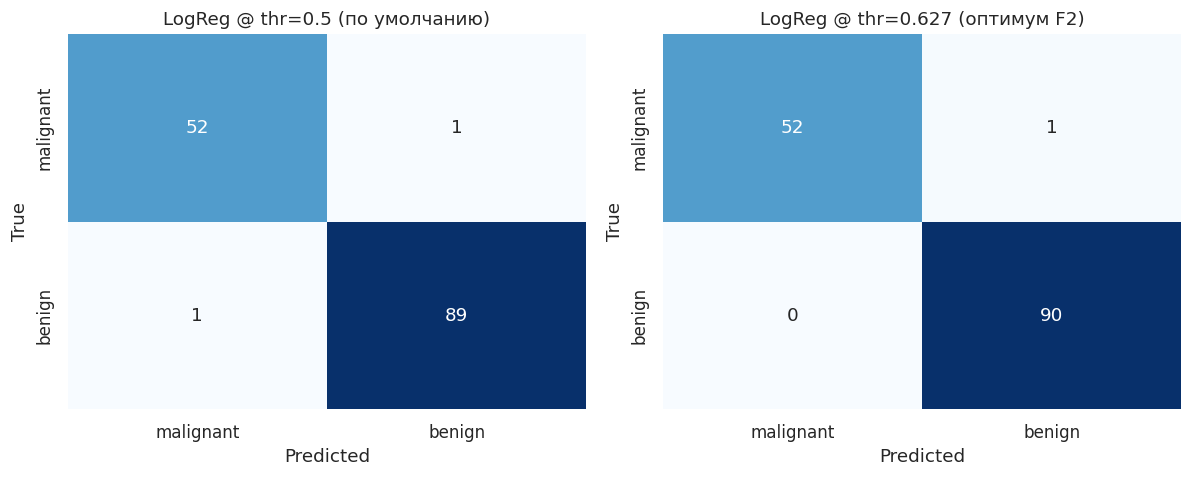

При оптимуме:
  TP (malignant найдена верно)   = 52
  FN (пропущен рак)              = 1  ← минимизируем именно это
  FP (ложная тревога)            = 0
  TN (benign верно)              = 90
  Всего malignant в тесте        = 53
  Всего benign в тесте           = 90


In [17]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))

y_pred_05 = (p_lr < 0.5).astype(int)
cm_05 = confusion_matrix(y_test, y_pred_05, labels=[0, 1])
plot_confusion(cm_05, CLASSES, 'LogReg @ thr=0.5 (по умолчанию)', axes[0])

y_pred_opt = (p_lr < opt_thr).astype(int)
cm_opt = confusion_matrix(y_test, y_pred_opt, labels=[0, 1])
plot_confusion(cm_opt, CLASSES, f'LogReg @ thr={opt_thr:.3f} (оптимум F2)', axes[1])

plt.tight_layout()
plt.savefig(ART_DIR / 'confusion_optimal.png', bbox_inches='tight')
plt.show()

tp_mal = int(cm_opt[0, 0])
fn_mal = int(cm_opt[0, 1])
fp_ben = int(cm_opt[1, 0])
tn_ben = int(cm_opt[1, 1])

print('При оптимуме:')
print(f'  TP (malignant найдена верно)   = {tp_mal}')
print(f'  FN (пропущен рак)              = {fn_mal}  ← минимизируем именно это')
print(f'  FP (ложная тревога)            = {fp_ben}')
print(f'  TN (benign верно)              = {tn_ben}')
print(f'  Всего malignant в тесте        = {tp_mal + fn_mal}')
print(f'  Всего benign в тесте           = {tn_ben + fp_ben}')

In [18]:
## 7. ROC-кривая и PR-кривая

#ROC показывает общий обзор, PR — точнее отражает качество по «интересующему» классу при небольшом дисбалансе

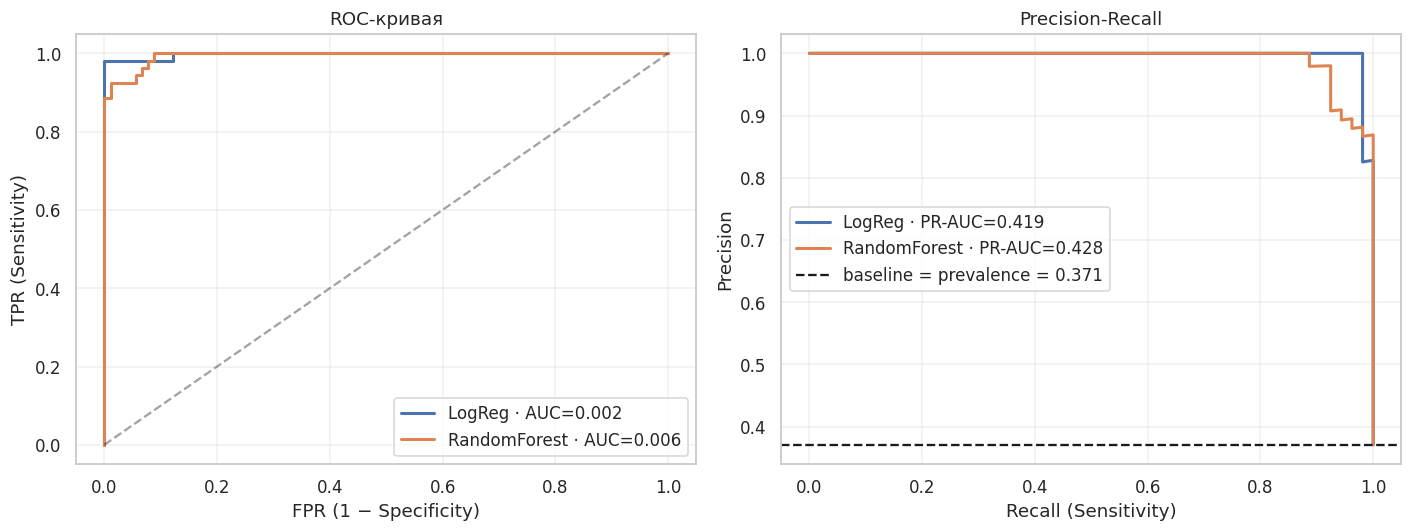

In [19]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

for name, proba in probas.items():
    # ROC
    fpr, tpr, _ = roc_curve(y_test, proba[:, 0], pos_label=0)
    auc = roc_auc_score(y_test, proba[:, 0])
    axes[0].plot(fpr, tpr, label=f'{name} · AUC={auc:.3f}', linewidth=2)

    # PR
    pr, rc, _ = precision_recall_curve(y_test, proba[:, 0], pos_label=0)
    ap = average_precision_score(y_test, proba[:, 0])
    axes[1].plot(rc, pr, label=f'{name} · PR-AUC={ap:.3f}', linewidth=2)

axes[0].plot([0, 1], [0, 1], 'k--', alpha=0.4)
axes[0].set_xlabel('FPR (1 − Specificity)')
axes[0].set_ylabel('TPR (Sensitivity)')
axes[0].set_title('ROC-кривая')
axes[0].legend()

axes[1].axhline((y_test == 0).mean(), color='k', ls='--',
                label=f'baseline = prevalence = {(y_test == 0).mean():.3f}')
axes[1].set_xlabel('Recall (Sensitivity)')
axes[1].set_ylabel('Precision')
axes[1].set_title('Precision-Recall')
axes[1].legend()

for ax in axes:
    ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig(ART_DIR / 'roc_pr.png', bbox_inches='tight')
plt.show()

In [20]:
## 8. Сравнение с ноутбуком 02 (цена FP высока)

#Выведем рядом оба оптимума:

#- `02_breast_cancer_fp`: оптимум по **F0.5** → порог сдвигается **вверх** от 0.5.
#- `03_breast_cancer_fn`: оптимум по **F2** → порог сдвигается **вниз** от 0.5.

# Тот же датасет. Тот же алгоритм. Разные бизнес-цели → разные метрики → разные пороги.

In [21]:
# Смотрим на разные пороги и соответствующие метрики
targets = [0.15, 0.30, 0.50, 0.70, 0.90]
nearest = sweep.index[np.abs(sweep.index.values[:, None] - np.array(targets)).argmin(axis=0)]

compare = sweep.loc[nearest,
                    ['f0.5_pos', 'f1_pos', 'f2_pos',
                     'recall_pos', 'precision_pos',
                     'sensitivity', 'specificity']]
compare.round(4)

,f0.5_pos,f1_pos,f2_pos,recall_pos,precision_pos,sensitivity,specificity
threshold,,,,,,,
0.142308,0.8997,0.9286,0.9594,0.9811,0.8814,0.9811,0.9222
0.303846,0.9253,0.9455,0.9665,0.9811,0.9123,0.9811,0.9444
0.511538,0.9811,0.9811,0.9811,0.9811,0.9811,0.9811,0.9889
0.696154,0.9881,0.9709,0.9542,0.9434,1.0000,0.9434,1.0000
0.903846,0.9705,0.9293,0.8915,0.8679,1.0000,0.8679,1.0000


In [22]:
## 9. Вывод

#Что мы увидели:

#1. `class_weight='balanced'` подтягивает recall по сравнению с дефолтным LogReg.
#2. Сдвиг порога вниз до 0.15–0.30 максимизирует Recall и F2 — мы **почти не пропускаем рак**.
#3. Precision падает, FP растут — но в этой постановке это приемлемо: лишняя биопсия дешевле пропущенного диагноза.
#4. Оптимум по F2 сдвинут **влево** от 0.5 — прямая противоположность ноутбуку 02.

#**Выбор метрики:**

#- Recall / Sensitivity — главная метрика, потому что FN критичен.
#- F2 — сводная метрика с β=2, штрафует FN в 4 раза сильнее FP.
#- Precision / Specificity — смотрим, но не оптимизируем.
#- Accuracy — не смотрим (высокая и так, ничего не различает).

#**Что сохраняем:**
#- Пайплайн LogReg с `class_weight='balanced'`.
#- Порог `opt_thr`, найденный по F2.
#- Метаданные с полным набором метрик.

In [23]:
model_path = MODEL_DIR / 'breast_cancer_fn.joblib'
meta_path  = MODEL_DIR / f'breast_cancer_fn_{datetime.now():%Y%m%d_%H%M}.json'

artifact = {
    'pipeline':       model_lr,          # StandardScaler + LogisticRegression (balanced)
    'threshold':      float(opt_thr),
    'positive_label': POS,               # 0 = malignant
    'classes':        CLASSES,
}

joblib.dump(artifact, model_path)

meta = {
    'task': 'breast_cancer_fn',
    'model': 'LogReg(bal)',
    'description': 'Второе мнение: минимизируем FN, целевая метрика F2 (malignant)',
    'threshold': float(opt_thr),
    'features': FEATURES,
    'classes': CLASSES,
    'positive_label': POS,
    'metrics_at_optimal': sweep.loc[opt_thr].round(4).to_dict(),
    'seed': SEED,
    'saved_at': datetime.now().isoformat(),
    'model_path': str(model_path.relative_to(PROJECT)),
}

meta_path.write_text(json.dumps(meta, indent=2, ensure_ascii=False))

print('saved model →', model_path)
print('saved meta  →', meta_path)

saved model → /app/models/classification/breast_cancer_fn/breast_cancer_fn.joblib
saved meta  → /app/models/classification/breast_cancer_fn/breast_cancer_fn_20261006_1428.json


In [24]:
sweep.round(6).to_csv(ART_DIR / 'threshold_sweep.csv')
metrics_table(results).to_csv(ART_DIR / 'metrics_all_models.csv')

(ART_DIR / 'metrics_all_models.json').write_text(
    json.dumps(results, indent=2, ensure_ascii=False)
)

print('artifacts →', ART_DIR)
for p in sorted(ART_DIR.iterdir()):
    print('  ', p.name)

artifacts → /app/artifacts/classification/breast_cancer_fn
   confusion_optimal.png
   eda.png
   metrics_all_models.csv
   metrics_all_models.json
   report.json
   results.json
   roc_pr.png
   threshold_sweep.csv
   threshold_sweep.png


In [25]:
## 10. Перезагрузка модели и проверка

##Убеждаемся, что артефакт `models/classification/breast_cancer_fn/breast_cancer_fn.joblib` работает идентично тому, что был в памяти.

In [26]:
art = joblib.load(model_path)

print('positive_label:', art['positive_label'])
print('threshold     :', art['threshold'])
print('classes       :', art['classes'])

p_reload = art['pipeline'].predict_proba(X_test)[:, art['positive_label']]
y_pred_reload = (p_reload < art['threshold']).astype(int)     # ← правильная кодировка

reload_metrics = all_metrics(
    y_test, y_pred_reload,
    np.c_[p_reload, 1 - p_reload],
    positive_label=art['positive_label'],
)

target_f2 = sweep.loc[opt_thr, 'f2_pos']
diff = abs(reload_metrics['f2_pos'] - target_f2)

print()
print(f'F2(malignant) после reload : {reload_metrics["f2_pos"]:.6f}')
print(f'F2(malignant) до сохранения: {target_f2:.6f}')
print(f'Расхождение                : {diff:.2e}')
print(f'Recall (malignant)         : {reload_metrics["recall_pos"]:.4f}')
print(f'Precision (malignant)      : {reload_metrics["precision_pos"]:.4f}')
print(f'Sensitivity                : {reload_metrics["sensitivity"]:.4f}')
print(f'Specificity                : {reload_metrics["specificity"]:.4f}')

assert diff < 1e-9, f'Расхождение больше допустимого: {diff}'

print()
print('OK: метрики после reload идентичны')
print()
print(pd.Series(reload_metrics).round(4))

positive_label: 0
threshold     : 0.6269230769230769
classes       : ['malignant', 'benign']

F2(malignant) после reload : 0.984848
F2(malignant) до сохранения: 0.984848
Расхождение                : 0.00e+00
Recall (malignant)         : 0.9811
Precision (malignant)      : 1.0000
Sensitivity                : 0.9811
Specificity                : 1.0000

OK: метрики после reload идентичны

accuracy             0.9930
balanced_accuracy    0.9906
precision_macro      0.9945
recall_macro         0.9906
f1_macro             0.9925
f1_weighted          0.9930
f0.5_macro           0.9937
f2_macro             0.9913
mcc                  0.9851
kappa                0.9850
precision_pos        1.0000
recall_pos           0.9811
f1_pos               0.9905
f0.5_pos             0.9962
f2_pos               0.9848
roc_auc              0.9977
pr_auc               0.9968
specificity          1.0000
sensitivity          0.9811
dtype: float64


In [27]:
art = joblib.load(model_path)

sample = X_test[0:1]
true_label = y_test[0]

p_mal = art['pipeline'].predict_proba(sample)[0, art['positive_label']]
# ВАЖНО: высокая P(malignant) ⇒ предсказываем malignant (метка 0)
pred_label = int(p_mal < art['threshold'])

print(f'Истинный класс : {CLASSES[true_label]}')
print(f'P(malignant)   : {p_mal:.4f}')
print(f'Порог (F2-опт) : {art["threshold"]:.2f}')
print(f'Предсказание   : {CLASSES[pred_label]}')
print(f'Решение        : {"отправить на повторное обследование" if pred_label == 0 else "рак не обнаружен"}')

Истинный класс : benign
P(malignant)   : 0.0310
Порог (F2-опт) : 0.63
Предсказание   : benign
Решение        : рак не обнаружен


In [28]:
## 11. Итог ноутбука

#Мы показали главный тезис серии:

#- **Метрика — не свойство данных, а свойство задачи.**
#- Один и тот же датасет Breast Cancer даёт **разные оптимальные модели**, если менять цену ошибки.
#- Сравните `breast_cancer_fp.joblib` и `breast_cancer_fn.joblib`:
#  - первый оптимизирован под precision (высокий порог),
#  - второй — под recall (низкий порог).
#- Обе модели правильно обучены, обе корректно сохранены. Какая из них «лучше» — зависит от того, кто их использует: скрининг или контрольное обследование.

#**Артефакты:**
#- `models/classification/breast_cancer_fn/breast_cancer_fn.joblib`
#- `models/classification/breast_cancer_fn/breast_cancer_fn_YYYYMMDD_HHMM.json`
#- `artifacts/classification/breast_cancer_fn/eda.png`
#- `artifacts/classification/breast_cancer_fn/threshold_sweep.png`
#- `artifacts/classification/breast_cancer_fn/threshold_sweep.csv`
#- `artifacts/classification/breast_cancer_fn/confusion_optimal.png`
#- `artifacts/classification/breast_cancer_fn/roc_pr.png`
#- `artifacts/classification/breast_cancer_fn/metrics_all_models.csv`
#- `artifacts/classification/breast_cancer_fn/metrics_all_models.json`

In [29]:
## 12. Сборка report.json + index.json для test.html

import json
from datetime import datetime
from pathlib import Path
import numpy as np
import pandas as pd
from sklearn.metrics import (
    classification_report, confusion_matrix, roc_auc_score,
    average_precision_score,
)

# ---------- хелперы ----------
def _to_native(obj):
    if isinstance(obj, dict):           return {k: _to_native(v) for k, v in obj.items()}
    if isinstance(obj, (list, tuple)):  return [_to_native(v) for v in obj]
    if isinstance(obj, np.ndarray):     return obj.tolist()
    if isinstance(obj, (np.integer,)):  return int(obj)
    if isinstance(obj, (np.floating,)): return float(obj)
    if isinstance(obj, (np.bool_,)):    return bool(obj)
    if isinstance(obj, pd.Series):      return obj.tolist()
    return obj

def _load_index(path):
    p = Path(path)
    if p.exists():
        return json.loads(p.read_text())
    return {"generated_at": None, "tasks": []}

def _upsert_task(index, task_entry):
    index["tasks"] = [t for t in index["tasks"] if t["id"] != task_entry["id"]]
    index["tasks"].append(task_entry)
    index["tasks"].sort(key=lambda t: t["id"])
    index["generated_at"] = datetime.now().isoformat()
    return index

# ---------- hero-метрика: F2 для malignant (положительный класс = 0) ----------
HERO_METRIC = 'f2_pos'

# В results 6 конфигураций (2 модели × 3 порога). Sweep нашёл оптимум opt_thr —
# добавляем его как отдельную конфигурацию.
opt_name = f'LogReg @thr={float(opt_thr):g}'
if opt_name not in results:
    p_opt_pred = (p_lr < opt_thr).astype(int)            # ← правильная кодировка
    results[opt_name] = all_metrics(
        y_test, p_opt_pred, np.c_[p_lr, 1 - p_lr], positive_label=POS
    )

best_name = max(results, key=lambda n: results[n][HERO_METRIC])
best_model_name, best_thr_str = best_name.split(' @thr=')
best_thr    = float(best_thr_str)
best_proba  = probas[best_model_name]                      # (n_test, 2), [:,0]=P(malignant)
best_pred   = (best_proba[:, POS] < best_thr).astype(int)  # ← правильная кодировка
best_conf   = np.max(best_proba, axis=1)
best_res    = results[best_name]

# ---------- базовые статистики датасета ----------
DATASET_STATS = {
    'n_samples':  int(len(X)),
    'n_features': int(len(FEATURES)),
    'n_classes':  int(len(CLASSES)),
    'n_train':    int(len(X_train)),
    'n_test':     int(len(X_test)),
}

counts_all  = {cls: int((y == i).sum())      for i, cls in enumerate(CLASSES)}
counts_test = {cls: int((y_test == i).sum()) for i, cls in enumerate(CLASSES)}

ratio = max(counts_all.values()) / max(min(counts_all.values()), 1)
TARGET_STATS = {
    'class_distribution':      counts_all,
    'class_distribution_test': counts_test,
    'is_balanced':             bool(ratio < 1.1),
    'imbalance_ratio':         float(ratio),
    'positive_label':          int(POS),
    'positive_class':          CLASSES[POS],
    'prevalence_positive':     float((y == POS).mean()),
}

# ---------- блок моделей ----------
models_block = []
for name, m in results.items():
    model_name, thr_part = name.split(' @thr=')
    thr = float(thr_part)

    y_proba = probas[model_name]
    y_pred  = (y_proba[:, POS] < thr).astype(int)          # ← правильная кодировка

    # per-class precision / recall / f1 / support
    cls_report = classification_report(
        y_test, y_pred, target_names=CLASSES,
        output_dict=True, zero_division=0,
    )
    per_class = {
        cls: {
            'precision': float(cls_report[cls]['precision']),
            'recall':    float(cls_report[cls]['recall']),
            'f1':        float(cls_report[cls]['f1-score']),
            'support':   int(cls_report[cls]['support']),
        } for cls in CLASSES
    }

    # confusion matrix — порядок [malignant(0), benign(1)]
    cm = confusion_matrix(y_test, y_pred, labels=[0, 1])
    tp_mal, fn_mal = int(cm[0, 0]), int(cm[0, 1])   # malignant: верно / пропущен
    fp_mal, tn_ben = int(cm[1, 0]), int(cm[1, 1])   # benign: ложная тревога / верно

    # ROC / PR по P(malignant); положительный класс — 0
    y_bin   = (y_test == POS).astype(int)
    roc_auc = float(roc_auc_score(y_bin, y_proba[:, POS]))
    pr_auc  = float(average_precision_score(y_bin, y_proba[:, POS]))

    mean_conf   = float(np.mean(np.max(y_proba, axis=1)))
    median_conf = float(np.median(np.max(y_proba, axis=1)))

    entry = {
        'name': name,
        'model': model_name,
        'threshold': thr,
        'is_best': name == best_name,
        'metrics': {k: float(v) for k, v in m.items()
                    if isinstance(v, (int, float, np.integer, np.floating))},
        'per_class':          per_class,
        'confusion_matrix':   cm.tolist(),
        'confusion_counts': {
            'tp_malignant': tp_mal,   # рак найден
            'fn_malignant': fn_mal,   # рак пропущен  ← КРИТИЧНО
            'fp_benign':    fp_mal,   # ложная тревога
            'tn_benign':    tn_ben,
        },
        'roc_auc':           roc_auc,
        'pr_auc':            pr_auc,
        'mean_confidence':   mean_conf,
        'median_confidence': median_conf,
    }

    # feature importance / coef
    m_obj = fitted[model_name]
    if hasattr(m_obj, 'feature_importances_'):
        fi = m_obj.feature_importances_
        entry['feature_importance'] = sorted(
            [{'name': f, 'value': float(v)} for f, v in zip(FEATURES, fi)],
            key=lambda x: x['value'], reverse=True,
        )
    elif hasattr(m_obj, 'named_steps') and 'm' in m_obj.named_steps \
         and hasattr(m_obj.named_steps['m'], 'coef_'):
        coef = m_obj.named_steps['m'].coef_
        if coef.ndim == 2:
            coef = coef[0]
        entry['feature_importance'] = sorted(
            [{'name': f, 'value': float(abs(c))} for f, c in zip(FEATURES, coef)],
            key=lambda x: x['value'], reverse=True,
        )

    models_block.append(entry)

best_entry = next(m for m in models_block if m['name'] == best_name)

# ---------- by_metric ----------
# roc_auc/pr_auc — threshold-free; sensitivity/recall — монотонно растут при ↓ порога.
# Для них нельзя осмысленно выбирать «лучший порог» по max(metric).
THRESHOLD_FREE  = {'roc_auc', 'pr_auc'}
MONOTONE_IN_THR = {'sensitivity', 'recall_pos', 'recall_macro'}

metric_keys = ['accuracy', 'balanced_accuracy', 'precision_macro', 'recall_macro',
               'f1_macro', 'f1_weighted', 'f0.5_macro', 'f2_macro', 'mcc', 'kappa',
               'roc_auc', 'pr_auc', 'specificity', 'sensitivity',
               'precision_pos', 'recall_pos', 'f1_pos', 'f0.5_pos', 'f2_pos']

by_metric = {}
for k in metric_keys:
    cands = [(n, results[n][k]) for n in results if k in results[n]]
    if not cands:
        continue

    if k in THRESHOLD_FREE:
        winner = max(cands, key=lambda t: t[1])[0]
        model_only = winner.split(' @thr=')[0]
        by_metric[k] = f'{model_only} (threshold-free)'
    elif k in MONOTONE_IN_THR:
        by_metric[k] = 'монотонно растёт при ↓ порога'
    else:
        by_metric[k] = max(cands, key=lambda t: t[1])[0]

# ---------- error_by_class у best-модели ----------
error_by_class = {}
for i, cls in enumerate(CLASSES):
    mask = (y_test == i)
    err  = float(np.mean(best_pred[mask] != i))
    error_by_class[cls] = {
        'support':    int(mask.sum()),
        'error_rate': err,
        'accuracy':   1.0 - err,
    }

# ---------- threshold sweep (данные для клиентского графика) ----------
threshold_sweep = {
    'model':             best_model_name,
    'optimal_threshold': float(opt_thr),
    'thresholds':        [float(t) for t in sweep.index],
    'precision_macro':   [float(v) for v in sweep['precision_macro']],
    'recall_macro':      [float(v) for v in sweep['recall_macro']],
    'f0.5_macro':        [float(v) for v in sweep['f0.5_macro']],
    'f1_macro':          [float(v) for v in sweep['f1_macro']],
    'f2_macro':          [float(v) for v in sweep['f2_macro']],
    'precision_pos':     [float(v) for v in sweep['precision_pos']],
    'recall_pos':        [float(v) for v in sweep['recall_pos']],
    'f0.5_pos':          [float(v) for v in sweep['f0.5_pos']],
    'f1_pos':            [float(v) for v in sweep['f1_pos']],
    'f2_pos':            [float(v) for v in sweep['f2_pos']],
    'specificity':       [float(v) for v in sweep['specificity']],
    'sensitivity':       [float(v) for v in sweep['sensitivity']],
}

# ---------- sample predictions ----------
correct_idx = np.where(best_pred == y_test)[0]
wrong_idx   = np.where(best_pred != y_test)[0]

# Разбиваем ошибки по типу — здесь FN приоритетнее
fn_idx = np.where((y_test == 0) & (best_pred == 1))[0]   # рак пропущен: КРИТИЧНО
fp_idx = np.where((y_test == 1) & (best_pred == 0))[0]   # здоровая → «рак»: допустимо

if len(correct_idx):
    correct_sorted = correct_idx[np.argsort(-best_conf[correct_idx])][:5]
else:
    correct_sorted = correct_idx

if len(wrong_idx):
    wrong_sorted = wrong_idx[np.argsort(-best_conf[wrong_idx])][:5]
else:
    wrong_sorted = wrong_idx

def _make_sample(idx):
    yt, yp = int(y_test[idx]), int(best_pred[idx])
    if   yt == 1 and yp == 0: et = 'fp'      # ложная тревога
    elif yt == 0 and yp == 1: et = 'fn'      # пропущенный рак ← главная ошибка
    else:                     et = 'correct'
    return {
        'features':   {f: float(v) for f, v in zip(FEATURES, X_test[idx])},
        'true':       CLASSES[yt],
        'predicted':  CLASSES[yp],
        'correct':    bool(yt == yp),
        'error_type': et,
        'confidence': float(best_conf[idx]),
        'proba':      {cls: float(p) for cls, p in zip(CLASSES, best_proba[idx])},
    }

sample_predictions = (
    [_make_sample(int(i)) for i in correct_sorted] +
    [_make_sample(int(i)) for i in wrong_sorted]
)

# ---------- headline diagnostics ----------
mal = best_entry['per_class']['malignant']

diag = {
    'is_balanced':         bool(TARGET_STATS['is_balanced']),
    'prevalence_positive': float(TARGET_STATS['prevalence_positive']),

    # Ключевое здесь: recall / sensitivity по malignant
    'recall_malignant':      float(mal['recall']),
    'precision_malignant':   float(mal['precision']),
    'specificity':           float(best_res['specificity']),
    'sensitivity':           float(best_res['sensitivity']),

    # Разрывы accuracy и др.
    'accuracy_vs_balanced_accuracy_gap': float(abs(best_res['accuracy'] - best_res['balanced_accuracy'])),
    'accuracy_vs_f1_macro_gap':          float(abs(best_res['accuracy'] - best_res['f1_macro'])),
    'accuracy_vs_f2_pos_gap':            float(abs(best_res['accuracy'] - best_res['f2_pos'])),
    'mcc':          float(best_res['mcc']),
    'kappa':        float(best_res['kappa']),
    'roc_auc':      float(best_res['roc_auc']),
    'pr_auc':       float(best_res['pr_auc']),

    # Порог и счётчики ошибок
    'best_threshold':        float(best_thr),
    'threshold_below_half':  bool(best_thr < 0.5),
    'fn_count_at_optimal':   int(len(fn_idx)),
    'fp_count_at_optimal':   int(len(fp_idx)),
    'fn_fp_ratio':           float(len(fn_idx) / max(len(fp_idx), 1)),
    'n_errors_on_test':      int(len(wrong_idx)),
    'metrics_are_consistent': bool(abs(best_res['accuracy'] - best_res['f1_macro']) < 0.05),
}

# ---------- charts ----------
charts = {}
for candidate in ['eda.png', 'threshold_sweep.png', 'confusion_optimal.png', 'roc_pr.png']:
    if (ART_DIR / candidate).exists():
        charts[candidate.replace('.png', '')] = candidate

# ---------- report ----------
ben = best_entry['per_class']['benign']

report = {
    'meta': {
        'task':     'breast_cancer_fn',
        'title':    'Breast Cancer · FN дорогой (второе мнение)',
        'subtitle': 'Пропущенный рак критичен — hero-метрика F2 по malignant, порог вниз',
        'dataset':  'sklearn.datasets.load_breast_cancer',
        'target':   'diagnosis',
        'target_unit':   '',
        'target_format': 'category',
        'classes':  CLASSES,
        'features': FEATURES,
        'seed':     SEED,
        'generated_at': datetime.now().isoformat(),
        **DATASET_STATS,
        'target_stats': TARGET_STATS,
        'narrative': {
            'context': (
                'Breast Cancer Wisconsin: 569 образцов, 30 числовых признаков. '
                '212 malignant / 357 benign (prevalence malignant ≈ 0.37). '
                'Модель работает как «второе мнение» / контрольный фильтр: '
                'FN = пропущенный рак (фатально), FP = лишнее обследование '
                '(допустимая цена). Мы намеренно жертвуем precision, чтобы '
                'вытащить максимум больных — пусть лучше здоровая пациентка '
                'пройдёт лишнюю биопсию, чем кто-то не пройдёт её вовсе.'
            ),
            'hero_metric': 'F2 (malignant)',
            'why_f2': (
                'β = 2 → FN штрафуется вчетверо сильнее FP (β² = 4). '
                'Именно это соответствует бизнес-задаче «не пропустить рак». '
                'Оптимизируем F2 ИМЕННО по malignant (pos_label=0), '
                'а не macro-F2: при несбалансированных классах macro-F2 '
                'размывает вклад интересующего класса.'
            ),
            'contrast_with_breast_cancer_fp': (
                'Тот же датасет, тот же алгоритм, что в 02_breast_cancer_fp. '
                'Там был F0.5 (FP дорог) → порог сдвигался вверх от 0.5. '
                'Здесь F2 (FN дорог) → порог сдвигается вниз от 0.5. '
                'Метрика — не свойство данных, а свойство задачи.'
            ),
            'main_conclusion': (
                f'Лучший порог по F2(malignant) = {best_thr:.2f} ({best_model_name}). '
                f'Malignant: recall={mal["recall"]:.3f}, precision={mal["precision"]:.3f}. '
                f'F2(malignant)={best_res["f2_pos"]:.4f}, '
                f'recall_macro={best_res["recall_macro"]:.4f}. '
                f'На тесте: FN={len(fn_idx)}, FP={len(fp_idx)} '
                f'(FN/FP={diag["fn_fp_ratio"]:.2f}). '
                'Accuracy здесь вторична: при imbalance её значение не отражает '
                'истинную способность модели ловить рак.'
            ),
            'rules': {
                'hero_f2_pos':           'Hero-метрика F2 по malignant, а не macro-F2 и не F1',
                'threshold_below_half':  f'Оптимум F2 = {best_thr:.2f} '
                                         f'({"< 0.5 → порог уведён вниз" if best_thr < 0.5 else "≥ 0.5"})',
                'recall_over_precision': 'Recall / Sensitivity для malignant смотрим в первую очередь; precision — во вторую',
            },
        },
    },
    'headline': {
        'best_model':        best_name,
        'best_metric':       HERO_METRIC,
        'best_metric_value': float(best_res[HERO_METRIC]),
        'verdict': (
            f'Лучшая конфигурация по F2(malignant) — {best_name} · '
            f'F2={best_res["f2_pos"]:.4f} · '
            f'recall(malignant)={mal["recall"]:.4f} · '
            f'sensitivity={best_res["sensitivity"]:.4f} · '
            f'FN={len(fn_idx)} / FP={len(fp_idx)}'
        ),
        'diagnostic_verdict': diag,
    },
    'models':             models_block,
    'by_metric':          by_metric,
    'error_by_class':     error_by_class,
    'threshold_sweep':    threshold_sweep,
    'sample_predictions': sample_predictions,
    'charts':             charts,
    'artifacts': {
        'model_joblib': str(model_path.relative_to(PROJECT)),
        'model_meta':   str(meta_path.relative_to(PROJECT)),
        'metrics_csv':  str((ART_DIR / 'metrics_all_models.csv').relative_to(PROJECT)),
        'metrics_json': str((ART_DIR / 'metrics_all_models.json').relative_to(PROJECT)),
        'sweep_csv':    str((ART_DIR / 'threshold_sweep.csv').relative_to(PROJECT)),
    },
}

report_path = ART_DIR / 'report.json'
report_path.write_text(json.dumps(_to_native(report), indent=2, ensure_ascii=False))

# ---------- index.json ----------
index_path = PROJECT / 'artifacts' / 'index.json'
index = _load_index(index_path)
index = _upsert_task(index, {
    'id':          'breast_cancer_fn',
    'title':       'Breast Cancer · FN дорогой',
    'best_model':  best_name,
    'hero_metric': 'f2_pos',
    'hero_value':  float(best_res['f2_pos']),
    'unit':        '',
    'report':      str(report_path.relative_to(PROJECT)),
    'charts_dir':  str(ART_DIR.relative_to(PROJECT)),
})
index_path.write_text(json.dumps(index, indent=2, ensure_ascii=False))

print('report  →', report_path)
print('index   →', index_path)
print('models  :', sorted(set(m['model'] for m in models_block)),
      f'({len(models_block)} конфигураций)')
print('best    :', best_name, f'F2(malignant) = {best_res["f2_pos"]:.4f}')
print('by_metric winners:')
for k, v in by_metric.items():
    print(f'  {k:18s} → {v}')
print('charts  :', list(charts.keys()))
print('optimal threshold  :', float(opt_thr),
      f'( {"< 0.5 ✓" if opt_thr < 0.5 else "≥ 0.5"} )')
print('FN / FP at optimal :', len(fn_idx), '/', len(fp_idx))
print('diag    :',
      f"recall(mal)={diag['recall_malignant']:.4f}",
      f"sensitivity={diag['sensitivity']:.4f}",
      f"fn_fp_ratio={diag['fn_fp_ratio']:.2f}")

report  → /app/artifacts/classification/breast_cancer_fn/report.json
index   → /app/artifacts/index.json
models  : ['LogReg', 'RandomForest'] (7 конфигураций)
best    : LogReg @thr=0.626923 F2(malignant) = 0.9848
by_metric winners:
  accuracy           → LogReg @thr=0.626923
  balanced_accuracy  → LogReg @thr=0.626923
  precision_macro    → LogReg @thr=0.626923
  recall_macro       → монотонно растёт при ↓ порога
  f1_macro           → LogReg @thr=0.626923
  f1_weighted        → LogReg @thr=0.626923
  f0.5_macro         → LogReg @thr=0.626923
  f2_macro           → LogReg @thr=0.626923
  mcc                → LogReg @thr=0.626923
  kappa              → LogReg @thr=0.626923
  roc_auc            → LogReg (threshold-free)
  pr_auc             → LogReg (threshold-free)
  specificity        → LogReg @thr=0.626923
  sensitivity        → монотонно растёт при ↓ порога
  precision_pos      → LogReg @thr=0.626923
  recall_pos         → монотонно растёт при ↓ порога
  f1_pos             → LogReg @